In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("../data/credit_dataset_cleaned.csv")

In [6]:
df.head()

,Age,Employment_Type,Annual_Income,Employment_Duration_Years,Number_of_Dependents,Loan_Purpose,Loan_Amount,Loan_Tenure_Months,Existing_Loans_Count,Total_Outstanding_Debt,...,Credit_Utilization,Previous_Defaults,Missed_Payments,Maximum_Days_Past_Due,Recent_Credit_Enquiries,Credit_History_Length,Number_of_Credit_Accounts,Payment_History,Credit_Score,Decision
0,21,Business Owner,631600,8.0,3,Home Renovation,263000,48,0,0,...,23.16,1,2,23,3,0.5,2,86.16,637,0
1,29,Business Owner,644100,10.9,3,Medical,651000,48,1,112300,...,27.53,0,0,0,1,7.7,3,100.00,698,1
2,28,Salaried,1018600,9.5,1,Personal,913000,36,0,0,...,31.55,0,0,0,3,2.3,3,100.00,677,1
3,30,Contract,901600,8.1,3,Medical,856000,48,2,739800,...,18.79,0,0,0,0,4.3,4,99.66,699,0
4,39,Salaried,1270100,6.3,0,Personal,463000,36,0,0,...,40.82,0,0,0,4,15.5,6,100.00,711,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        30000 non-null  int64  
 1   Employment_Type            30000 non-null  object 
 2   Annual_Income              30000 non-null  int64  
 3   Employment_Duration_Years  30000 non-null  float64
 4   Number_of_Dependents       30000 non-null  int64  
 5   Loan_Purpose               30000 non-null  object 
 6   Loan_Amount                30000 non-null  int64  
 7   Loan_Tenure_Months         30000 non-null  int64  
 8   Existing_Loans_Count       30000 non-null  int64  
 9   Total_Outstanding_Debt     30000 non-null  int64  
 10  Existing_Monthly_EMI       30000 non-null  int64  
 11  Debt_to_Income_Ratio       30000 non-null  float64
 12  Loan_to_Income_Ratio       30000 non-null  float64
 13  Credit_Utilization         30000 non-null  flo

In [8]:
print("\nNumerical columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical columns:")
print(df.select_dtypes(include="object").columns.tolist())


Numerical columns:
['Age', 'Annual_Income', 'Employment_Duration_Years', 'Number_of_Dependents', 'Loan_Amount', 'Loan_Tenure_Months', 'Existing_Loans_Count', 'Total_Outstanding_Debt', 'Existing_Monthly_EMI', 'Debt_to_Income_Ratio', 'Loan_to_Income_Ratio', 'Credit_Utilization', 'Previous_Defaults', 'Missed_Payments', 'Maximum_Days_Past_Due', 'Recent_Credit_Enquiries', 'Credit_History_Length', 'Number_of_Credit_Accounts', 'Payment_History', 'Credit_Score', 'Decision']

Categorical columns:
['Employment_Type', 'Loan_Purpose']


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,30000.0,3.604800e+01,8.207664,21.00,30.00,36.000,42.00,65.00
Annual_Income,30000.0,7.283103e+05,366836.977704,180000.00,471275.00,652900.000,897100.00,4628500.00
Employment_Duration_Years,30000.0,5.590333e+00,3.029603,0.50,3.40,5.500,7.70,18.50
Number_of_Dependents,30000.0,1.589733e+00,1.253821,0.00,1.00,1.000,2.00,6.00
Loan_Amount,30000.0,1.103774e+06,802105.754046,50000.00,511000.00,919000.000,1475000.00,5000000.00
Loan_Tenure_Months,30000.0,4.653960e+01,19.795441,12.00,36.00,48.000,60.00,84.00
Existing_Loans_Count,30000.0,9.106000e-01,1.035942,0.00,0.00,1.000,2.00,4.00
Total_Outstanding_Debt,30000.0,2.533139e+05,428307.515527,0.00,0.00,58800.000,349825.00,5817200.00
Existing_Monthly_EMI,30000.0,7.594150e+03,13138.868543,0.00,0.00,1660.000,10390.00,227120.00
Debt_to_Income_Ratio,30000.0,6.322795e+01,27.498567,5.00,40.16,64.790,95.00,95.00


In [10]:
print(df["Decision"].value_counts())

Decision
0    18583
1    11417
Name: count, dtype: int64


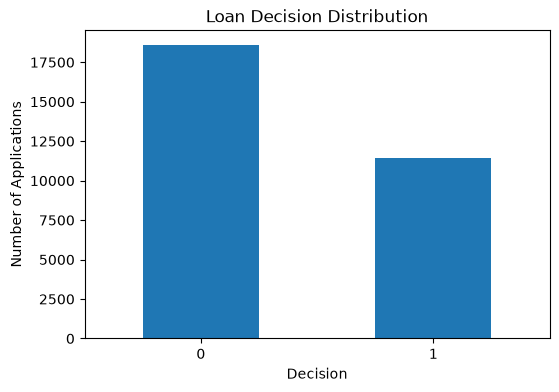

In [11]:
df["Decision"].value_counts().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Loan Decision Distribution")
plt.xlabel("Decision")
plt.ylabel("Number of Applications")
plt.xticks(rotation=0)
plt.show()

In [12]:
numerical_features = df.select_dtypes(
    include=np.number
).columns.tolist()

numerical_features.remove("Decision")

print(numerical_features)

['Age', 'Annual_Income', 'Employment_Duration_Years', 'Number_of_Dependents', 'Loan_Amount', 'Loan_Tenure_Months', 'Existing_Loans_Count', 'Total_Outstanding_Debt', 'Existing_Monthly_EMI', 'Debt_to_Income_Ratio', 'Loan_to_Income_Ratio', 'Credit_Utilization', 'Previous_Defaults', 'Missed_Payments', 'Maximum_Days_Past_Due', 'Recent_Credit_Enquiries', 'Credit_History_Length', 'Number_of_Credit_Accounts', 'Payment_History', 'Credit_Score']


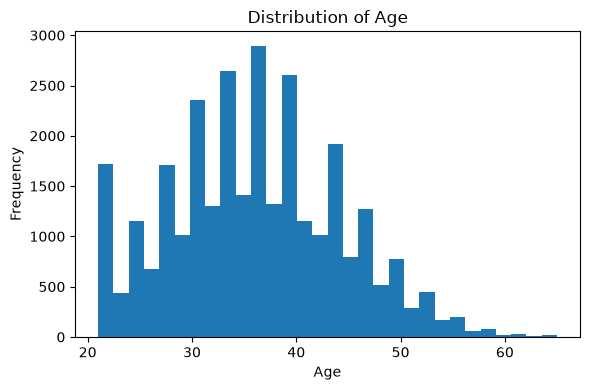

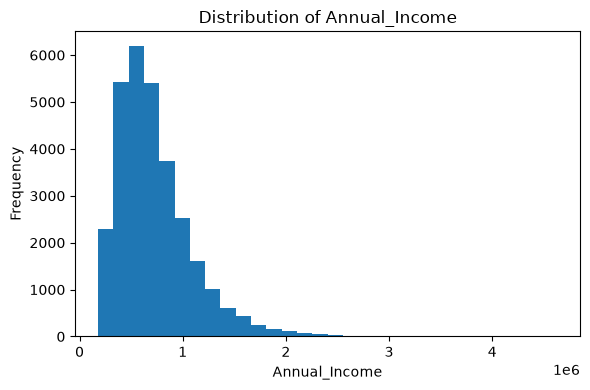

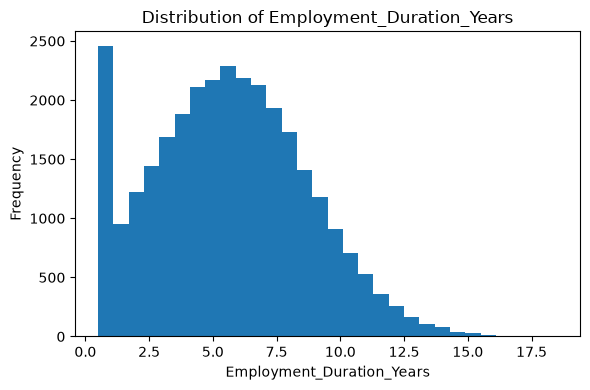

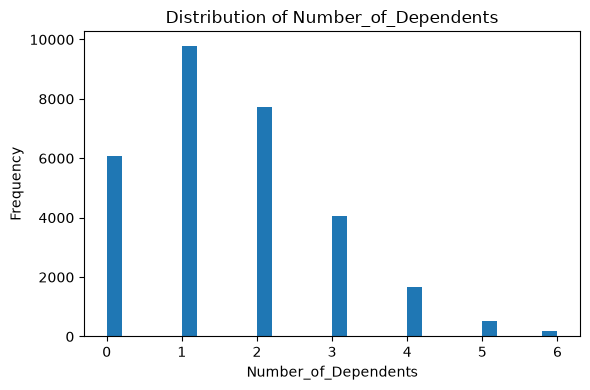

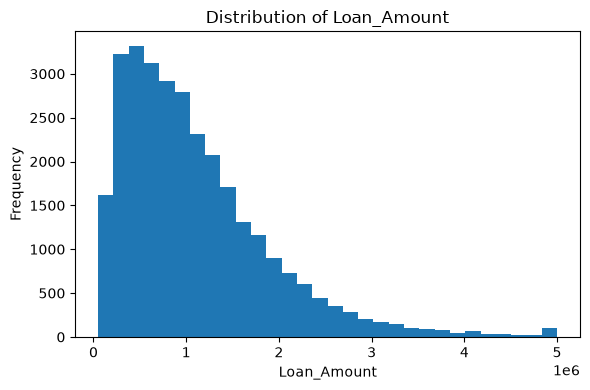

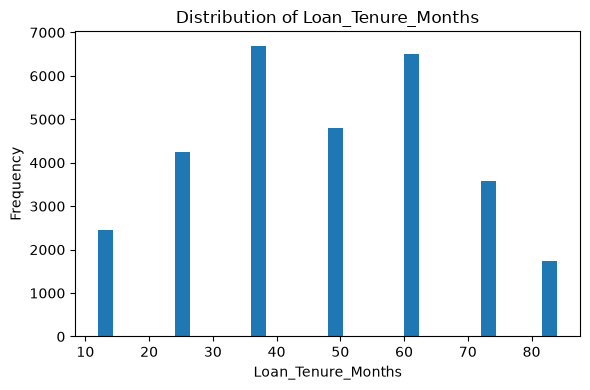

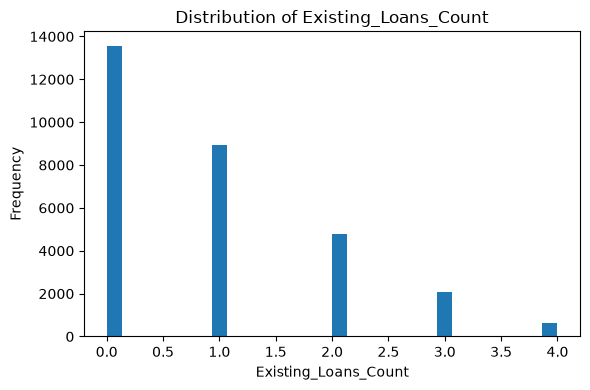

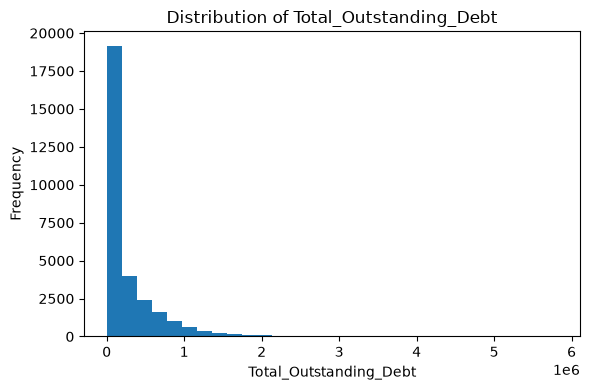

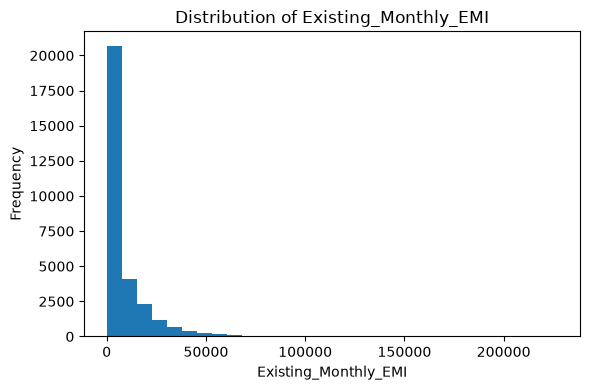

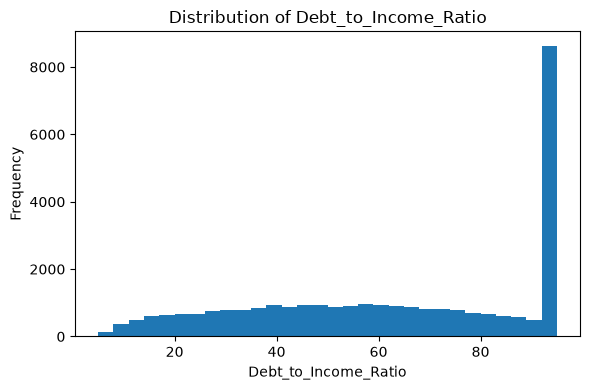

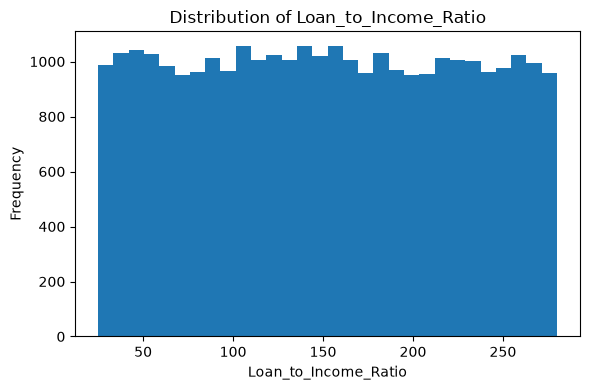

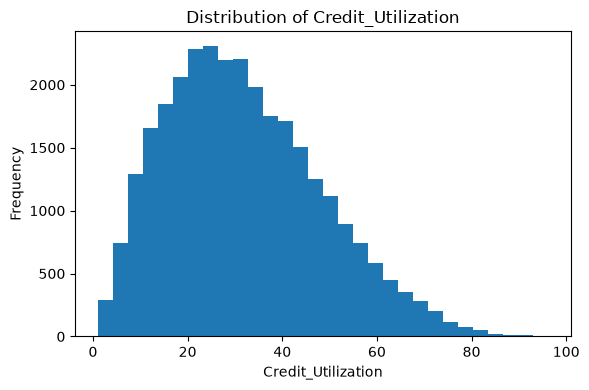

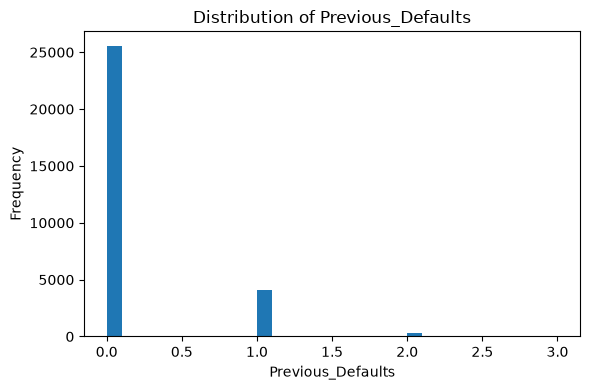

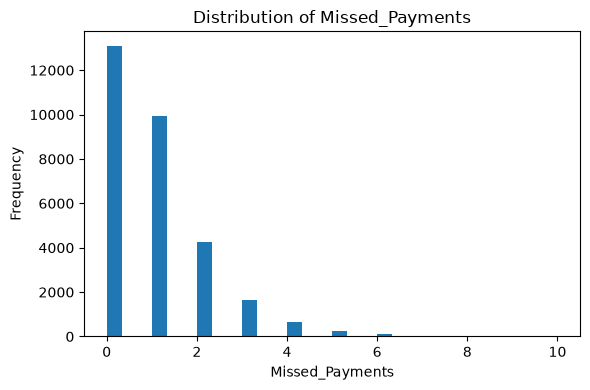

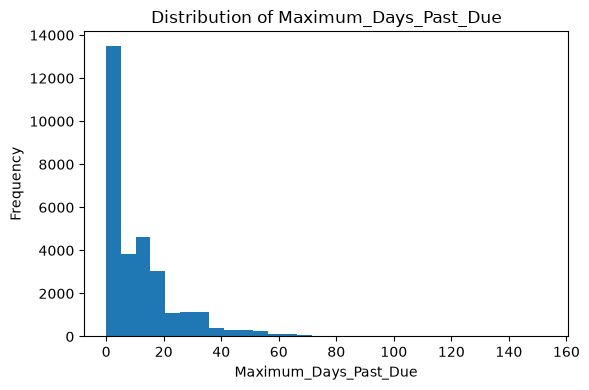

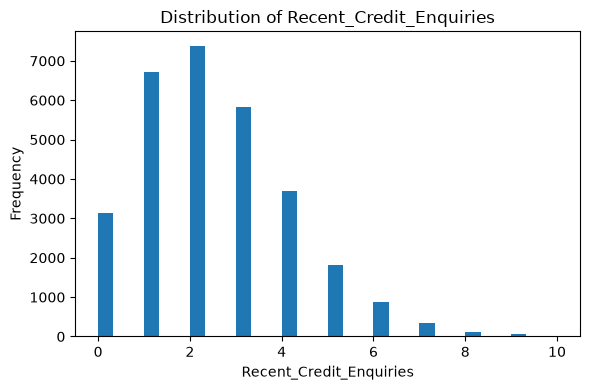

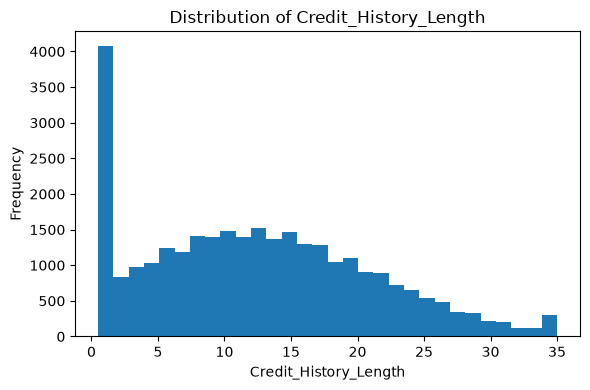

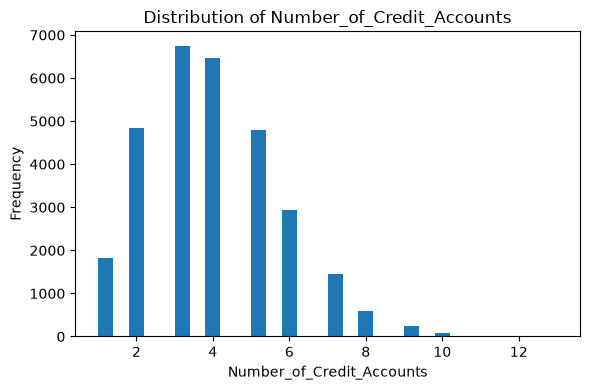

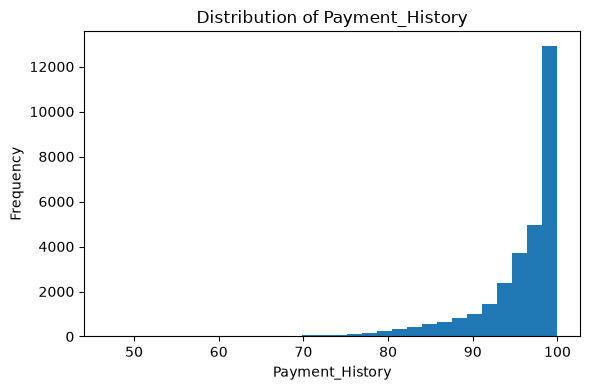

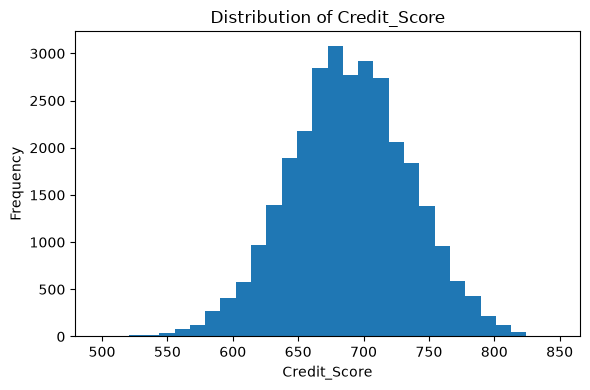

In [13]:
for column in numerical_features:
    plt.figure(figsize=(6, 4))
    
    plt.hist(df[column], bins=30)
    
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()

In [14]:
print(df["Employment_Type"].value_counts())

Employment_Type
Salaried          17646
Self-Employed      4370
Professional       3032
Business Owner     2916
Contract           2036
Name: count, dtype: int64


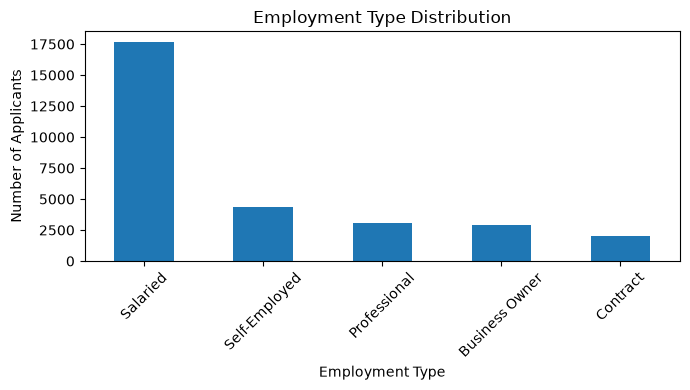

In [15]:
df["Employment_Type"].value_counts().plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Employment Type Distribution")
plt.xlabel("Employment Type")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
print(df["Loan_Purpose"].value_counts())

Loan_Purpose
Personal            9106
Home                4523
Vehicle             4481
Business            3617
Education           2979
Medical             2326
Home Renovation     1787
Consumer Durable    1181
Name: count, dtype: int64


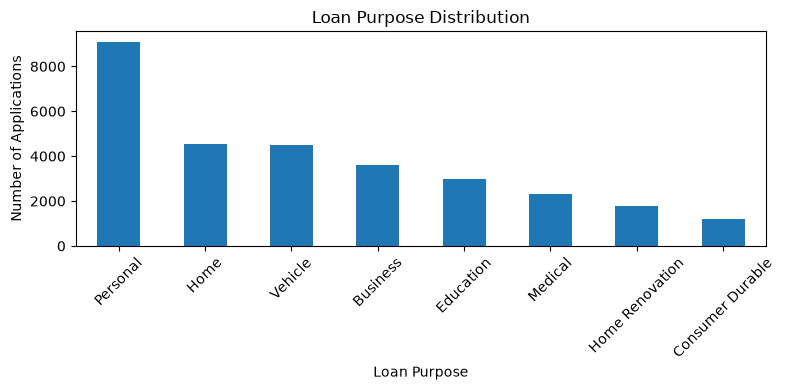

In [17]:
df["Loan_Purpose"].value_counts().plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Loan Purpose Distribution")
plt.xlabel("Loan Purpose")
plt.ylabel("Number of Applications")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

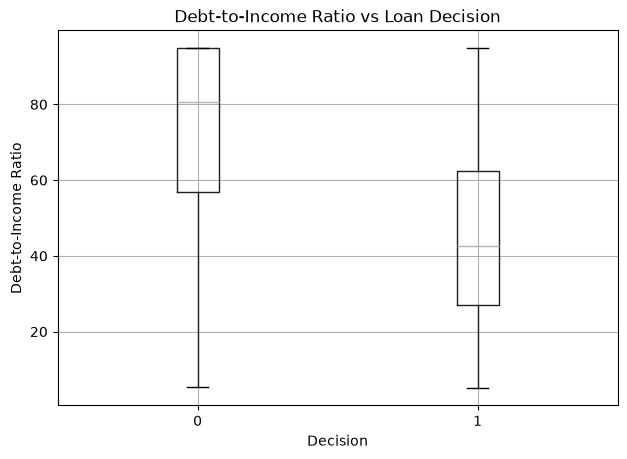

In [18]:
df.boxplot(
    column="Debt_to_Income_Ratio",
    by="Decision",
    figsize=(7, 5)
)

plt.title("Debt-to-Income Ratio vs Loan Decision")
plt.suptitle("")
plt.xlabel("Decision")
plt.ylabel("Debt-to-Income Ratio")

plt.show()

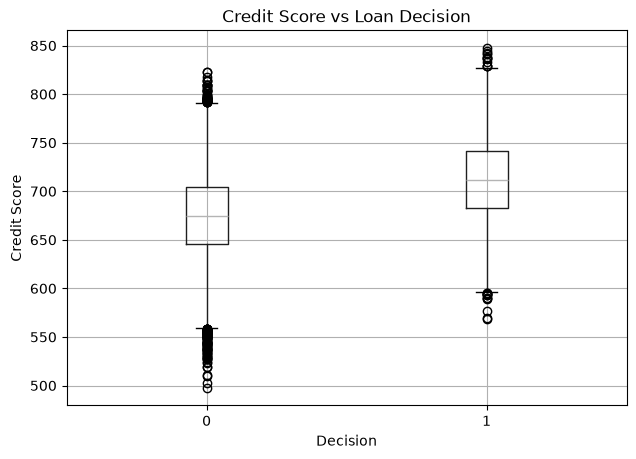

In [19]:
df.boxplot(
    column="Credit_Score",
    by="Decision",
    figsize=(7, 5)
)

plt.title("Credit Score vs Loan Decision")
plt.suptitle("")
plt.xlabel("Decision")
plt.ylabel("Credit Score")

plt.show()

In [20]:
default_decision = pd.crosstab(
    df["Previous_Defaults"],
    df["Decision"],
    normalize="index"
) * 100

print(default_decision.round(2))

Decision               0      1
Previous_Defaults              
0                  58.49  41.51
1                  80.70  19.30
2                  94.74   5.26
3                  93.75   6.25


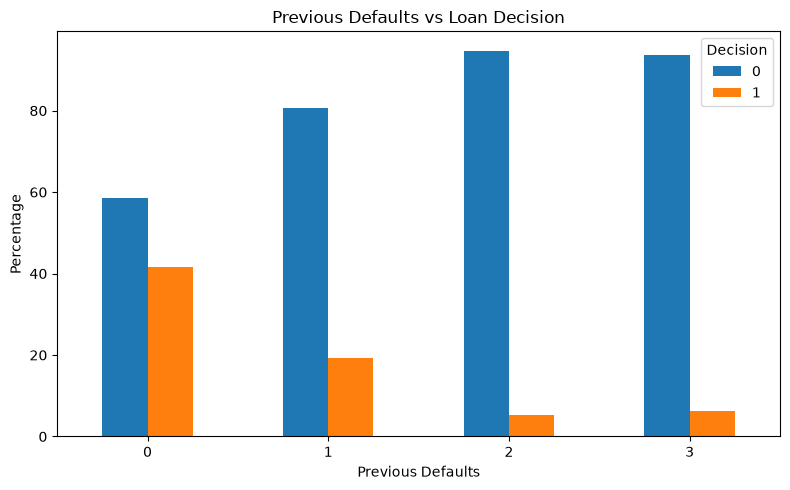

In [21]:
default_decision.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Previous Defaults vs Loan Decision")
plt.xlabel("Previous Defaults")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.legend(title="Decision")
plt.tight_layout()
plt.show()

In [22]:
missed_payment_decision = pd.crosstab(
    df["Missed_Payments"],
    df["Decision"],
    normalize="index"
) * 100

print(missed_payment_decision.round(2))

Decision              0      1
Missed_Payments               
0                 56.26  43.74
1                 61.03  38.97
2                 69.00  31.00
3                 78.20  21.80
4                 83.69  16.31
5                 89.84  10.16
6                 92.52   7.48
7                 97.56   2.44
8                100.00   0.00
9                100.00   0.00
10               100.00   0.00


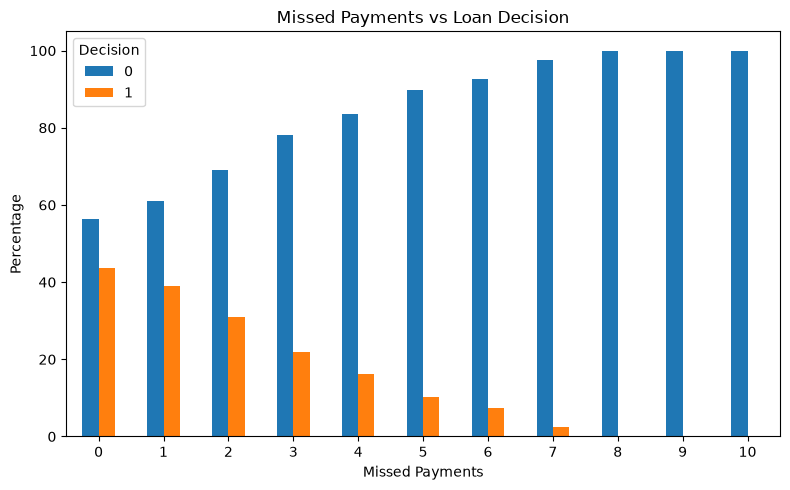

In [23]:
missed_payment_decision.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Missed Payments vs Loan Decision")
plt.xlabel("Missed Payments")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.legend(title="Decision")
plt.tight_layout()
plt.show()

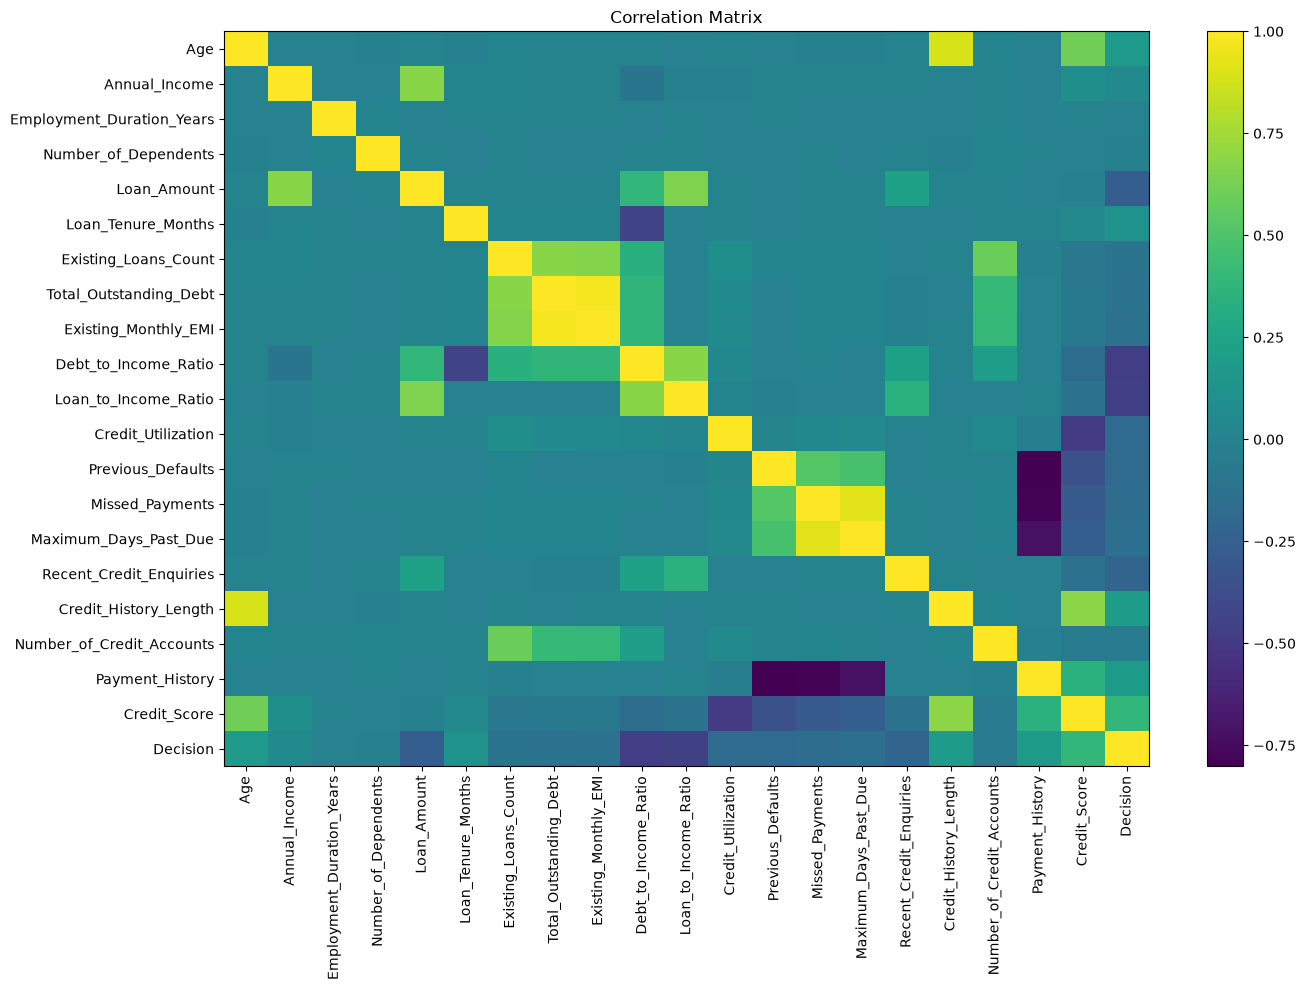

In [24]:
correlation_matrix = df[numerical_features + ["Decision"]].corr()

plt.figure(figsize=(14, 10))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [25]:
decision_correlation = (
    correlation_matrix["Decision"]
    .drop("Decision")
    .sort_values(key=abs, ascending=False)
)

print(decision_correlation)

Debt_to_Income_Ratio        -0.476662
Loan_to_Income_Ratio        -0.457341
Credit_Score                 0.394352
Loan_Amount                 -0.266012
Recent_Credit_Enquiries     -0.212117
Credit_History_Length        0.197575
Payment_History              0.178018
Age                          0.176078
Previous_Defaults           -0.172116
Credit_Utilization          -0.170881
Missed_Payments             -0.156339
Maximum_Days_Past_Due       -0.143982
Existing_Monthly_EMI        -0.118922
Loan_Tenure_Months           0.118674
Total_Outstanding_Debt      -0.118443
Existing_Loans_Count        -0.107583
Number_of_Credit_Accounts   -0.065660
Annual_Income                0.061034
Number_of_Dependents        -0.006296
Employment_Duration_Years   -0.004268
Name: Decision, dtype: float64


In [27]:
feature_correlation = df[numerical_features].corr()

high_correlations = []

for i in range(len(feature_correlation.columns)):
    for j in range(i + 1, len(feature_correlation.columns)):
        
        correlation = feature_correlation.iloc[i, j]
        
        if abs(correlation) >= 0.80:
            high_correlations.append(
                (
                    feature_correlation.columns[i],
                    feature_correlation.columns[j],
                    correlation
                )
            )

high_correlations

[('Age', 'Credit_History_Length', np.float64(0.8943126304711159)),
 ('Total_Outstanding_Debt',
  'Existing_Monthly_EMI',
  np.float64(0.9761228146576076)),
 ('Previous_Defaults', 'Payment_History', np.float64(-0.8008124651097585)),
 ('Missed_Payments', 'Maximum_Days_Past_Due', np.float64(0.9198032620006289))]

In [28]:
high_corr_df = pd.DataFrame(
    high_correlations,
    columns=["Feature_1", "Feature_2", "Correlation"]
)

high_corr_df = high_corr_df.sort_values(
    by="Correlation",
    key=abs,
    ascending=False
)

high_corr_df

,Feature_1,Feature_2,Correlation
1,Total_Outstanding_Debt,Existing_Monthly_EMI,0.976123
3,Missed_Payments,Maximum_Days_Past_Due,0.919803
0,Age,Credit_History_Length,0.894313
2,Previous_Defaults,Payment_History,-0.800812
